In [1]:
import pandas as pd
import zipfile
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

In [2]:
df1_test = pd.read_csv('test1.csv')
model1= joblib.load('model1.pkl')

In [6]:
X_test1 = df1_test.drop(columns=["IsAtRisk"])
y_test1 = df1_test["IsAtRisk"]

y_pred = model1.predict(X_test1)
print("Accuracy:", accuracy_score(y_test1, y_pred))

Accuracy: 0.8378378378378378


In [7]:
print(classification_report(y_test1, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.65      0.71        57
           1       0.86      0.92      0.89       128

    accuracy                           0.84       185
   macro avg       0.82      0.79      0.80       185
weighted avg       0.83      0.84      0.83       185



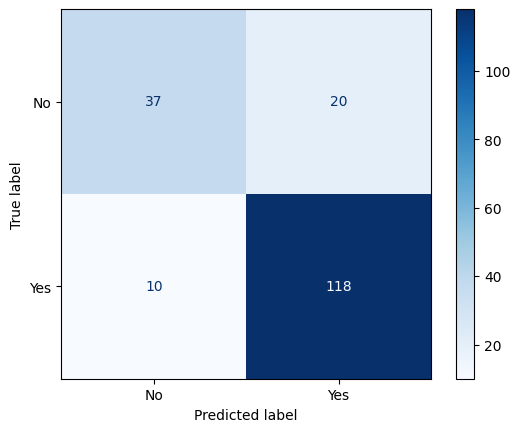

In [8]:
cm = confusion_matrix(y_test1, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])

disp.plot(cmap=plt.cm.Blues)
plt.savefig("cm_dataset1.png", dpi=150, bbox_inches='tight')
plt.show()

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model1.predict_proba(X_test1)[:, 1]
auc = roc_auc_score(y_test1, y_prob)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.999


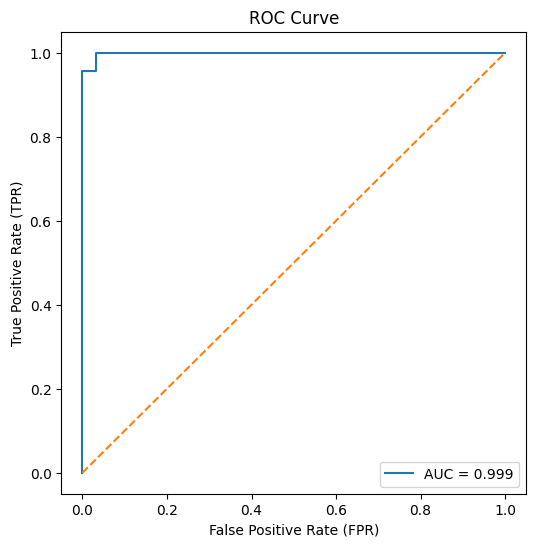

In [29]:
y_prob = model1.predict_proba(X_test1)[:, 1]

fpr, tpr, _ = roc_curve(y_test1, y_prob)
auc = roc_auc_score(y_test1, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
acc1 = accuracy_score(y_test1, model1.predict(X_test1))

metrics = {
    "dataset_1": {"accuracy": round(acc1, 4), "ROC-AUC": round(auc, 4)}
}

with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)
    
print("Metrics successfully saved to metrics.json")